In [36]:
import xgboost as xgb
# load model from json
model_price = xgb.Booster()
model_price.load_model("../results/models/xgb_price.model")
model_news = xgb.Booster()
model_news.load_model("../results/models/xgb_price_news.model")
model_emb = xgb.Booster()
model_emb.load_model("../results/models/xgb_price_news_emb.model")

/tmp/ipykernel_1559625/1351945173.py:4: UserWarning: [11:50:16] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1763746907527/work/src/c_api/c_api.cc:1511: Unknown file format: `model`. Using UBJSON (`ubj`) as a guess.
  model_price.load_model("../results/models/xgb_price.model")
/tmp/ipykernel_1559625/1351945173.py:6: UserWarning: [11:50:16] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1763746907527/work/src/c_api/c_api.cc:1511: Unknown file format: `model`. Using UBJSON (`ubj`) as a guess.
  model_news.load_model("../results/models/xgb_price_news.model")
/tmp/ipykernel_1559625/1351945173.py:8: UserWarning: [11:50:16] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1763746907527/work/src/c_api/c_api.cc:1511: Unknown file format: `model`. Using UBJSON (`ubj`) as a guess.
  model_emb.load_model("../results/models/xgb_price_news_emb.model")


Loading data...
Adding targets...
Adding price features...
Adding news features...
Num embedding cols: 64
Total features for emb model: 114
Loading XGBoost model...
Generating predictions on test set...


/tmp/ipykernel_1559625/1645678508.py:153: UserWarning: [11:50:23] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1763746907527/work/src/c_api/c_api.cc:1511: Unknown file format: `model`. Using UBJSON (`ubj`) as a guess.
  model.load_model(path)


Building prediction and return matrices...
Prediction matrix shape: (250, 500)
Return matrix shape:     (250, 500)
Running top-K backtest...
Backtest length (days): 249

=== Backtest Performance (Top-K Long Only) ===
Total return:         46.89%
Annualized return:    47.57%
Annualized vol:       20.57%
Sharpe ratio:         2.313
Max drawdown:        -14.54%

Plotting equity curve...


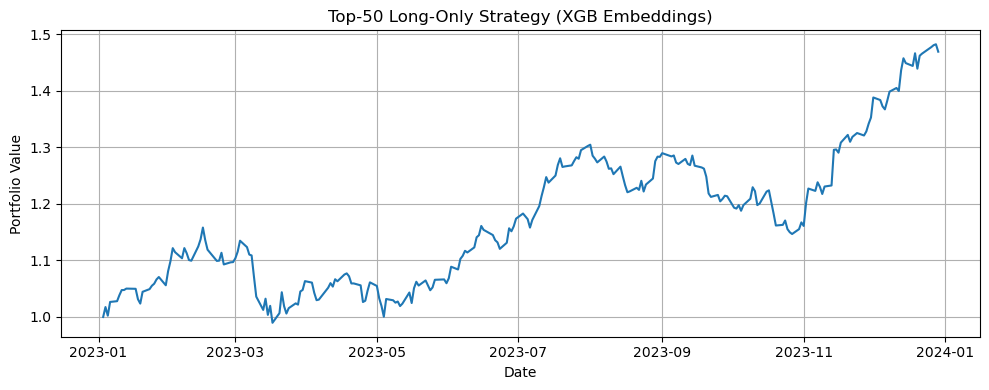

In [37]:

import os
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

from typing import List, Tuple


# ---------------------------------------------------------------------
# 0. Paths & config
# ---------------------------------------------------------------------
DATA_DIR = "../data/model"
MODEL_PATH = "../results/models/xgb_price_news_emb.model"

TRAIN_PATH = os.path.join(DATA_DIR, "final_train.parquet")
VAL_PATH   = os.path.join(DATA_DIR, "final_val.parquet")
TEST_PATH  = os.path.join(DATA_DIR, "final_test.parquet")

PRED_COL_NAME = "pred_emb"   # column name for predictions in test
TOP_K = 50                   # size of long portfolio
RISK_FREE = 0.0              # assume 0 RF for Sharpe (daily RF ≈ 0)
TRADING_DAYS = 252           # for annualization


# ---------------------------------------------------------------------
# 1. Feature engineering (same as your notebook)
# ---------------------------------------------------------------------

news_features = [
    "mean_sentiment", "max_sentiment", "min_sentiment",
    "sum_sentiment", "news_count"
]


def add_target(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(["tic", "Date"]).copy()
    grp_close = df.groupby("tic")["Close"]
    df["ret_1d_raw"] = grp_close.pct_change(1)
    df["target_1d"] = df.groupby("tic")["ret_1d_raw"].shift(-1)
    return df


def add_price_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(["tic", "Date"]).copy()

    grp_close = df.groupby("tic")["Close"]
    grp_ret   = df.groupby("tic")["ret_1d_raw"]
    grp_vol   = df.groupby("tic")["Volume"]

    # Price momentum
    df["ret_1d_lag"] = grp_close.pct_change(1)
    df["ret_2d"]     = grp_close.pct_change(2)
    df["ret_3d"]     = grp_close.pct_change(3)
    df["ret_5d"]     = grp_close.pct_change(5)
    df["ret_10d"]    = grp_close.pct_change(10)

    # Overnight/intraday
    prev_close = grp_close.shift(1)
    df["overnight_ret"] = df["Open"] / prev_close - 1
    df["intraday_ret"]  = df["Close"] / df["Open"] - 1

    # RSI(14)
    delta = grp_close.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    roll_up = gain.groupby(df["tic"]).rolling(14).mean().reset_index(0, drop=True)
    roll_down = loss.groupby(df["tic"]).rolling(14).mean().reset_index(0, drop=True)
    df["RSI"] = 100 - (100 / (1 + roll_up / roll_down))

    # Volatility
    df["vol_3d"]  = grp_ret.rolling(3).std().reset_index(0, drop=True)
    df["vol_5d"]  = grp_ret.rolling(5).std().reset_index(0, drop=True)
    df["vol_10d"] = grp_ret.rolling(10).std().reset_index(0, drop=True)

    # High-Low range
    df["range_vol"] = np.log(df["High"] / df["Low"]) ** 2

    # Liquidity
    mean_vol = grp_vol.transform("mean")
    std_vol  = grp_vol.transform("std")
    df["turnover"] = df["Volume"] / mean_vol
    df["vol_z"]    = (df["Volume"] - mean_vol) / std_vol
    df["amihud"]   = (np.abs(df["ret_1d_raw"]) / df["Volume"]).replace(np.inf, np.nan)

    df = df.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return df


def add_news_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(["tic", "Date"]).copy()
    grp = df.groupby("tic")

    for f in news_features:
        # lagged sentiment
        df[f + "_lag1"] = grp[f].shift(1)

        # rolling windows (leak-free, ending at t)
        df[f + "_roll3"] = grp[f].rolling(3).mean().reset_index(0, drop=True)
        df[f + "_roll5"] = grp[f].rolling(5).mean().reset_index(0, drop=True)

        # sentiment volatility
        df[f + "_vol5"] = grp[f].rolling(5).std().reset_index(0, drop=True)

        # shocks and surprises
        df[f + "_shock"] = df[f] - df[f + "_lag1"]
        df[f + "_surprise3"] = df[f] - df[f + "_roll3"]

    return df.fillna(0.0)


def get_feature_lists(train: pd.DataFrame) -> Tuple[List[str], List[str], List[str], List[str]]:
    """
    Construct feature lists:
    - price_features
    - news_momentum_features
    - emb_cols (PCA news embeddings)
    - all_features_with_emb (for emb model)
    """
    price_features = [
        "ret_1d_lag", "ret_2d", "ret_3d", "ret_5d", "ret_10d",
        "overnight_ret", "intraday_ret",
        "RSI",
        "vol_3d", "vol_5d", "vol_10d",
        "range_vol",
        "turnover", "vol_z", "amihud"
    ]

    news_momentum_features: List[str] = []
    for f in news_features:
        news_momentum_features += [
            f,
            f + "_lag1",
            f + "_roll3",
            f + "_roll5",
            f + "_vol5",
            f + "_shock",
            f + "_surprise3",
        ]

    emb_cols = [c for c in train.columns if c.startswith("pca_emb_")]
    all_features_with_emb = price_features + news_momentum_features + emb_cols

    return price_features, news_momentum_features, emb_cols, all_features_with_emb


# ---------------------------------------------------------------------
# 2. Model prediction helpers
# ---------------------------------------------------------------------

def load_xgb_model(path: str) -> xgb.Booster:
    model = xgb.Booster()
    model.load_model(path)
    return model


def predict_returns(model: xgb.Booster,
                    df: pd.DataFrame,
                    feature_cols: List[str]) -> np.ndarray:
    dmat = xgb.DMatrix(df[feature_cols].values, feature_names=feature_cols)
    preds = model.predict(dmat)
    return preds


# ---------------------------------------------------------------------
# 3. Backtest helpers
# ---------------------------------------------------------------------

def build_prediction_and_return_matrices(
    test: pd.DataFrame,
    pred_col: str
) -> Tuple[np.ndarray, np.ndarray, pd.Index, pd.Index]:
    """
    Build pivot tables so that predictions and realized returns are aligned
    (T x N matrices).

    Returns:
        pred_mat: T x N matrix of predictions at date t
        ret_mat:  T x N matrix of realized *next-day* returns at date t
                 (we will use ret_mat[t+1] in the backtest loop)
        dates:    index of dates (length T)
        tickers:  index of tickers (length N)
    """
    test = test.copy()
    # ensure Date is datetime
    if not np.issubdtype(test["Date"].dtype, np.datetime64):
        test["Date"] = pd.to_datetime(test["Date"])

    # pivot: rows=Date, cols=tic
    pred_pivot = test.pivot(index="Date", columns="tic", values=pred_col)
    ret_pivot  = test.pivot(index="Date", columns="tic", values="ret_1d_raw")

    # sort by date just in case
    pred_pivot = pred_pivot.sort_index()
    ret_pivot  = ret_pivot.reindex(index=pred_pivot.index, columns=pred_pivot.columns)

    # fill missing values: if we don't have prediction or return, treat as 0
    pred_pivot = pred_pivot.fillna(0.0)
    ret_pivot  = ret_pivot.fillna(0.0)

    pred_mat = pred_pivot.values   # T x N
    ret_mat  = ret_pivot.values    # T x N

    dates   = pred_pivot.index
    tickers = pred_pivot.columns

    return pred_mat, ret_mat, dates, tickers


def top_k_long_weights(preds: np.ndarray, k: int) -> np.ndarray:
    """
    Simple long-only strategy: invest 1/k in the top k predicted names.
    """
    n = len(preds)
    w = np.zeros(n)
    if k <= 0:
        return w
    k = min(k, n)
    top_idx = np.argsort(preds)[-k:]
    w[top_idx] = 1.0 / k
    return w


def run_backtest_top_k(
    pred_mat: np.ndarray,
    ret_mat: np.ndarray,
    k: int = TOP_K
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Given T x N prediction matrix and T x N realized return matrix,
    run daily-rebalanced top-K long strategy.

    Uses predictions at day t to choose weights, then realizes returns at t+1.
    """
    T, N = pred_mat.shape
    assert ret_mat.shape == (T, N)

    portfolio_vals = [1.0]
    daily_returns = []

    capital = 1.0

    for t in range(T - 1):
        preds = pred_mat[t, :]       # length N
        w = top_k_long_weights(preds, k)

        realized = ret_mat[t + 1, :]  # next-day realized returns

        # portfolio return = w · realized
        port_ret = float(np.dot(w, realized))
        daily_returns.append(port_ret)

        capital *= (1.0 + port_ret)
        portfolio_vals.append(capital)

    return np.array(daily_returns), np.array(portfolio_vals)


# ---------------------------------------------------------------------
# 4. Evaluation metrics
# ---------------------------------------------------------------------

def compute_performance_metrics(
    daily_returns: np.ndarray,
    portfolio_vals: np.ndarray,
    risk_free: float = RISK_FREE,
    trading_days: int = TRADING_DAYS
) -> dict:
    """
    Compute standard backtest performance metrics.
    """
    T = len(daily_returns)
    if T == 0:
        raise ValueError("No daily returns to evaluate.")

    total_return = portfolio_vals[-1] - 1.0

    # annualized return
    ann_return = (portfolio_vals[-1]) ** (trading_days / T) - 1.0

    # annualized volatility
    vol = np.std(daily_returns, ddof=1)
    ann_vol = vol * np.sqrt(trading_days)

    # Sharpe (assuming RF ~ 0)
    if ann_vol > 0:
        sharpe = (ann_return - risk_free) / ann_vol
    else:
        sharpe = np.nan

    # max drawdown
    pv = portfolio_vals
    roll_max = np.maximum.accumulate(pv)
    drawdown = (pv - roll_max) / roll_max
    max_dd = drawdown.min()

    return {
        "total_return": total_return,
        "ann_return": ann_return,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "max_drawdown": max_dd,
    }


def plot_equity_curve(dates: pd.Index, portfolio_vals: np.ndarray, title: str = ""):
    plt.figure(figsize=(10, 4))
    plt.plot(dates, portfolio_vals, linewidth=1.5)
    plt.xlabel("Date")
    plt.ylabel("Portfolio Value")
    plt.title(title or "Equity Curve")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------
# 5. Main
# ---------------------------------------------------------------------


print("Loading data...")
train = pd.read_parquet(TRAIN_PATH)
val   = pd.read_parquet(VAL_PATH)
test  = pd.read_parquet(TEST_PATH)

# sort
train = train.sort_values(["tic", "Date"]).reset_index(drop=True)
val   = val.sort_values(["tic", "Date"]).reset_index(drop=True)
test  = test.sort_values(["tic", "Date"]).reset_index(drop=True)

# Ensure Date is datetime
for df in [train, val, test]:
    if not np.issubdtype(df["Date"].dtype, np.datetime64):
        df["Date"] = pd.to_datetime(df["Date"])

print("Adding targets...")
train = add_target(train)
val   = add_target(val)
test  = add_target(test)

print("Adding price features...")
train = add_price_features(train)
val   = add_price_features(val)
test  = add_price_features(test)

print("Adding news features...")
train = add_news_features(train)
val   = add_news_features(val)
test  = add_news_features(test)

# drop rows with NaN target
train = train[~train["target_1d"].isna()].copy()
val   = val[~val["target_1d"].isna()].copy()
test  = test[~test["target_1d"].isna()].copy()

# feature lists
price_features, news_momentum_features, emb_cols, all_features_with_emb = get_feature_lists(train)

print(f"Num embedding cols: {len(emb_cols)}")
print(f"Total features for emb model: {len(all_features_with_emb)}")

print("Loading XGBoost model...")
model = load_xgb_model(MODEL_PATH)

print("Generating predictions on test set...")
test[PRED_COL_NAME] = predict_returns(model, test, all_features_with_emb)

print("Building prediction and return matrices...")
pred_mat, ret_mat, dates, tickers = build_prediction_and_return_matrices(
    test, PRED_COL_NAME
)

print(f"Prediction matrix shape: {pred_mat.shape}")  # (T, N)
print(f"Return matrix shape:     {ret_mat.shape}")   # (T, N)

print("Running top-K backtest...")
daily_rets, pv = run_backtest_top_k(pred_mat, ret_mat, k=TOP_K)

print(f"Backtest length (days): {len(daily_rets)}")

metrics = compute_performance_metrics(daily_rets, pv)
print("\n=== Backtest Performance (Top-K Long Only) ===")
print(f"Total return:        {metrics['total_return']*100:6.2f}%")
print(f"Annualized return:   {metrics['ann_return']*100:6.2f}%")
print(f"Annualized vol:      {metrics['ann_vol']*100:6.2f}%")
print(f"Sharpe ratio:        {metrics['sharpe']:6.3f}")
print(f"Max drawdown:        {metrics['max_drawdown']*100:6.2f}%")

print("\nPlotting equity curve...")
plot_equity_curve(dates, pv, title=f"Top-{TOP_K} Long-Only Strategy (XGB Embeddings)")


In [38]:
import numpy as np
from sklearn.metrics import mean_squared_error

def compute_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    da = (np.sign(y_true) == np.sign(y_pred)).mean()
    return rmse, da



In [39]:
import xgboost as xgb

def xgb_predict(model, df, features):
    dmat = xgb.DMatrix(df[features].values)
    return model.predict(dmat)


In [40]:
results = {}
y_val = val["target_1d"].values
y_test = test["target_1d"].values
# 1. Price model
y_val_price = xgb_predict(model_price, val, price_features)
y_test_price = xgb_predict(model_price, test, price_features)

results["price"] = {
    "val_rmse": compute_metrics(y_val, y_val_price)[0],
    "val_da":   compute_metrics(y_val, y_val_price)[1],
    "test_rmse": compute_metrics(y_test, y_test_price)[0],
    "test_da":   compute_metrics(y_test, y_test_price)[1],
}

# 2. Price + News model
y_val_news = xgb_predict(model_news, val, price_features + news_momentum_features)
y_test_news = xgb_predict(model_news, test, price_features + news_momentum_features)

results["news"] = {
    "val_rmse": compute_metrics(y_val, y_val_news)[0],
    "val_da":   compute_metrics(y_val, y_val_news)[1],
    "test_rmse": compute_metrics(y_test, y_test_news)[0],
    "test_da":   compute_metrics(y_test, y_test_news)[1],
}

# 3. Price + News + Embeddings model
y_val_emb = xgb_predict(model_emb, val, all_features_with_emb)
y_test_emb = xgb_predict(model_emb, test, all_features_with_emb)

results["emb"] = {
    "val_rmse": compute_metrics(y_val, y_val_emb)[0],
    "val_da":   compute_metrics(y_val, y_val_emb)[1],
    "test_rmse": compute_metrics(y_test, y_test_emb)[0],
    "test_da":   compute_metrics(y_test, y_test_emb)[1],
}


In [41]:
import pandas as pd

summary_df = pd.DataFrame(results).T
summary_df


,val_rmse,val_da,test_rmse,test_da
price,0.024242,0.497487,0.018404,0.512888
news,0.024242,0.496445,0.018394,0.513465
emb,0.024234,0.495627,0.018362,0.513850


In [42]:
def run_backtest_for_predictions(test, pred_col, top_k=50):
    pred_mat, ret_mat, dates, tickers = build_prediction_and_return_matrices(test, pred_col)
    daily_rets, pv = run_backtest_top_k(pred_mat, ret_mat, k=top_k)
    metrics = compute_performance_metrics(daily_rets, pv)
    return metrics, dates, pv


In [43]:
# Add predictions to test df
test["pred_price"] = y_test_price
test["pred_news"]  = y_test_news
test["pred_emb"]   = y_test_emb

bt_results = {}

for name in ["pred_price", "pred_news", "pred_emb"]:
    metrics, dates, pv = run_backtest_for_predictions(test, name)
    bt_results[name] = metrics


In [44]:
pd.DataFrame(bt_results).T


,total_return,ann_return,ann_vol,sharpe,max_drawdown
pred_price,0.433395,0.439627,0.211293,2.080654,-0.159005
pred_news,0.417219,0.423185,0.211348,2.002311,-0.168021
pred_emb,0.468915,0.475736,0.205705,2.312717,-0.145407


In [45]:
test["pred_random"] = np.random.normal(0, 0.01, size=len(test))
metrics, _, _ = run_backtest_for_predictions(test, "pred_random")
metrics


{'total_return': np.float64(0.14814147123063548),
 'ann_return': np.float64(0.15005401970508414),
 'ann_vol': np.float64(0.14473132862029392),
 'sharpe': np.float64(1.036776357513821),
 'max_drawdown': np.float64(-0.13942589175071723)}

In [46]:
# Pivot close prices
price_pivot = test.pivot(index="Date", columns="tic", values="Close").sort_index()

# Daily returns
ret_pivot = price_pivot.pct_change().fillna(0)

# Number of stocks
N = ret_pivot.shape[1]

# Buy & Hold = equal weight on day 1, no rebalancing
initial_weights = np.ones(N) / N

# Daily portfolio returns
bh_daily = (ret_pivot * initial_weights).sum(axis=1)

# Portfolio value
bh_pv = (1 + bh_daily).cumprod()

# Compute performance metrics
bh_metrics = compute_performance_metrics(bh_daily.values, bh_pv.values)
bh_metrics


{'total_return': np.float64(0.2084179854573398),
 'ann_return': np.float64(0.2102495167595202),
 'ann_vol': np.float64(0.1410840535318387),
 'sharpe': np.float64(1.4902429544390203),
 'max_drawdown': np.float64(-0.12186846216660598)}

In [61]:
import cvxpy as cp
import numpy as np

def solve_cvar_weights(
    preds,
    scenario_returns,
    w_prev=None,
    alpha=0.95,
    lam=5.0,
    max_weight=0.02,
    ret_scale=10.0,
    turnover_limit=0.10,
    tx_cost=0.0005,
):
    """
    Mean–CVaR optimizer (long-only, position limits, turnover & tx costs).

    maximize   (preds_scaled @ w) - lam * CVaR_alpha(loss) - tx_cost * sum(u)
    s.t.       sum(w) = 1
               0 <= w <= max_weight
               L1 turnover <= turnover_limit

    preds:            vector of predicted *daily* returns (length N)
    scenario_returns: matrix of realized daily returns (T_scen x N)
    w_prev:           previous-day weights (length N). If None, use equal-weight.
    """

    T_scen, N = scenario_returns.shape

    if w_prev is None:
        w_prev = np.ones(N) / N
    else:
        w_prev = np.asarray(w_prev).flatten()
        if w_prev.shape[0] != N:
            raise ValueError("w_prev must have length N.")

    # Scale preds so they are comparable in magnitude to CVaR term
    preds_scaled = preds * ret_scale

    w = cp.Variable(N)
    z = cp.Variable(T_scen)
    v = cp.Variable()
    # u_i ≈ |w_i - w_prev_i|
    u = cp.Variable(N)

    # Scenario losses: negative portfolio returns
    loss = -scenario_returns @ w

    cvar_term = v + (1.0 / ((1 - alpha) * T_scen)) * cp.sum(z)
    objective = cp.Maximize(preds_scaled @ w - lam * cvar_term - tx_cost * cp.sum(u))

    constraints = [
        cp.sum(w) == 1,
        w >= 0,
        w <= max_weight,      # position limit (e.g. 2% per name)

        z >= 0,
        z >= loss - v,

        u >= 0,
        u >= w - w_prev,
        u >= -(w - w_prev),
        cp.sum(u) <= turnover_limit,  # L1 turnover constraint
    ]

    prob = cp.Problem(objective, constraints)

    try:
        prob.solve(solver=cp.SCS, verbose=False, max_iters=5000)
    except Exception:
        # If solver explodes, fall back to equal-weight
        return np.ones(N) / N

    if w.value is None or prob.status not in ["optimal", "optimal_inaccurate"]:
        # Fallback: equal-weight portfolio
        return np.ones(N) / N

    # Safeguard: project small numerical issues back to a valid simplex
    w_val = np.maximum(w.value, 0)
    s = w_val.sum()
    if s <= 0:
        return np.ones(N) / N
    return (w_val / s).flatten()


In [62]:
def run_backtest_cvar(
    pred_mat,
    ret_mat,
    window=60,
    alpha=0.95,
    lam=5.0,
    ret_scale=10.0,
    max_weight=0.02,
    turnover_limit=0.10,
    tx_cost=0.0005,
):
    """
    Rolling CVaR backtest.

    - Uses past `window` days as scenarios for CVaR.
    - Rebalances every day with turnover & tx-cost-aware optimizer.
    """

    T, N = pred_mat.shape

    daily_returns = np.full(T, np.nan)
    portfolio_vals = np.full(T, np.nan)

    capital = 1.0
    portfolio_vals[window] = capital

    # start with equal weight
    w_prev = np.ones(N) / N

    for t in range(window, T - 1):
        preds = pred_mat[t]
        scenario = ret_mat[t-window:t]   # window x N

        w = solve_cvar_weights(
            preds,
            scenario,
            w_prev=w_prev,
            alpha=alpha,
            lam=lam,
            max_weight=max_weight,
            ret_scale=ret_scale,
            turnover_limit=turnover_limit,
            tx_cost=tx_cost,
        )

        realized = ret_mat[t + 1]
        port_ret = float(np.dot(w, realized))

        capital *= (1 + port_ret)
        daily_returns[t + 1] = port_ret
        portfolio_vals[t + 1] = capital

        w_prev = w

    return daily_returns, portfolio_vals


In [49]:
daily_topk, pv_topk = run_backtest_top_k(pred_mat, ret_mat, k=TOP_K)
metrics_topk = compute_performance_metrics(daily_topk[1:], pv_topk[1:])
metrics_topk

{'total_return': np.float64(0.46891544110811334),
 'ann_return': np.float64(0.47805397188680376),
 'ann_vol': np.float64(0.20549157516322833),
 'sharpe': np.float64(2.3263920747459874),
 'max_drawdown': np.float64(-0.1454070442867501)}

In [63]:
daily_cvar, pv_cvar = run_backtest_cvar(
    pred_mat,
    ret_mat,
    window=60,
    alpha=0.95,
    lam=5.0,
    ret_scale=10.0,
    max_weight=0.02,
    turnover_limit=0.10,
    tx_cost=0.0005,
)

valid_idx = ~np.isnan(daily_cvar)
metrics_cvar = compute_performance_metrics(daily_cvar[valid_idx], pv_cvar[valid_idx])
metrics_cvar


/home/zeyuzh/.conda/envs/jupyter_env/lib/python3.13/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


{'total_return': np.float64(0.09401146391406834),
 'ann_return': np.float64(0.12727315260499195),
 'ann_vol': np.float64(0.09585669420658258),
 'sharpe': np.float64(1.3277440209934965),
 'max_drawdown': np.float64(-0.08700772165586407)}

In [87]:
def run_buy_and_hold(ret_mat):
    """
    ret_mat: T x N matrix of daily returns
             ret_mat[t, i] = return of stock i on day t

    Buy & Hold:
        - allocate 1/N on day 0
        - NO rebalancing
        - portfolio value = product over days of (1 + w · ret_t)
    """

    T, N = ret_mat.shape

    # equal initial weights
    w0 = np.ones(N) / N

    portfolio_vals = [1.0]
    daily_returns = []

    capital = 1.0
    w = w0.copy()

    for t in range(T):
        # portfolio return: fixed weights
        port_ret = float(np.dot(w, ret_mat[t]))
        daily_returns.append(port_ret)
        capital *= (1 + port_ret)
        portfolio_vals.append(capital)

        # weights drift automatically due to asset returns

    return np.array(daily_returns), np.array(portfolio_vals)


In [88]:
daily_bh, pv_bh = run_buy_and_hold(ret_mat)
metrics_bh = compute_performance_metrics(daily_bh, pv_bh)
metrics_bh


{'total_return': np.float64(0.20841798545734025),
 'ann_return': np.float64(0.21024951675952064),
 'ann_vol': np.float64(0.1410840535318387),
 'sharpe': np.float64(1.4902429544390234),
 'max_drawdown': np.float64(-0.12186846216660598)}

In [89]:
def plot_comparison_safe(dates, pv_dict):
    plt.figure(figsize=(12, 5))

    T = len(dates)

    for name, pv in pv_dict.items():
        pv = np.array(pv, dtype=float)

        # ---- Align lengths ----
        if len(pv) < T:
            # pad at front with NaN for missing days
            pad_len = T - len(pv)
            pv = np.concatenate([np.full(pad_len, np.nan), pv])
        elif len(pv) > T:
            pv = pv[:T]

        # now same length as dates
        valid = ~np.isnan(pv)
        plt.plot(dates[valid], pv[valid], label=name, linewidth=2)

    plt.title("Equity Curve Comparison: Buy & Hold vs Top-K vs CVaR", fontsize=14)
    plt.xlabel("Date")
    plt.ylabel("Portfolio Value")
    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()


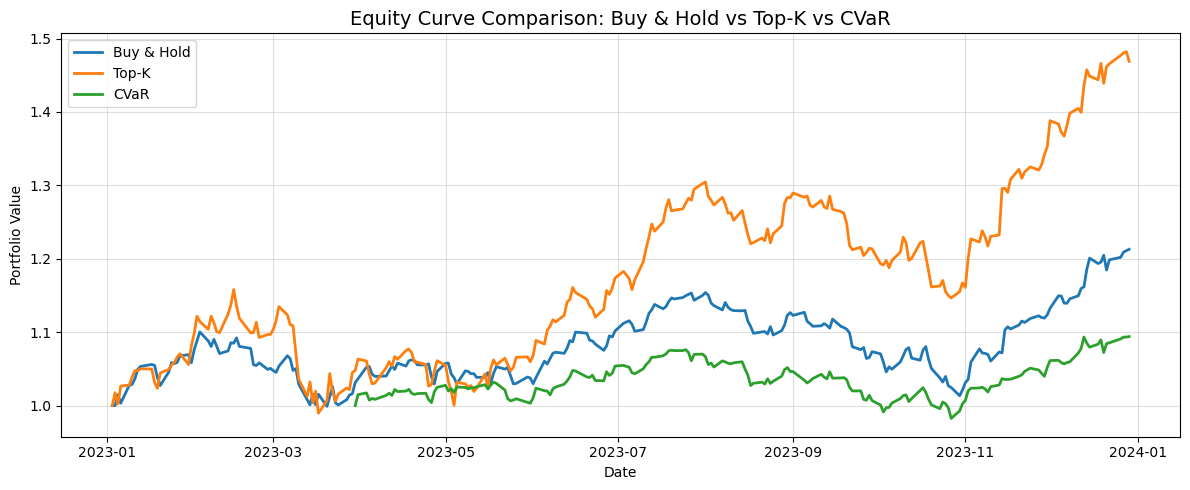

In [90]:
plot_comparison_safe(
    dates,
    {
        "Buy & Hold": pv_bh,
        "Top-K": pv_topk,
        "CVaR": pv_cvar
    }
)
